# Практическое задание №3. Задача классификации на Kaggle с помощью логистической регрессии (light)
**Описание:**
Нефтегазовая отрасль имеет сложную технологическую цепочку, которая начинается с геологической разведки и заканчивается доставкой нефти и газа потребителям. Одной из важных задач является определение места залежей — на суше или в море — на основе различных параметров.

**Ваша задача:** разработать алгоритм машинного обучения, который позволит классифицировать место залежей нефти и газа.


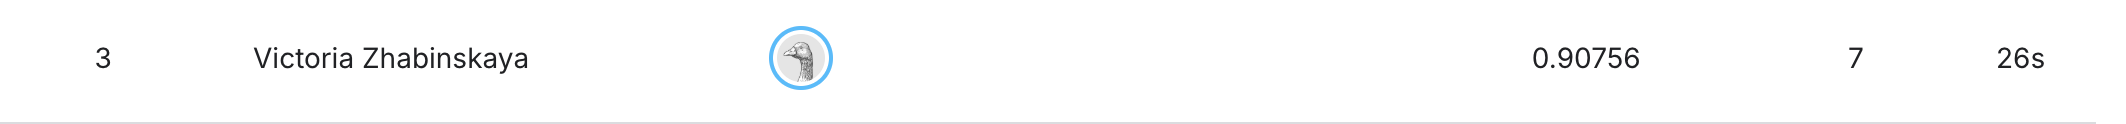

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score, precision_score, recall_score
from imblearn.over_sampling import ADASYN
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

!pip install xgboost -q
!pip install lightgbm -q
!pip install catboost -q

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

### Исследование и анализ датасета

In [2]:
train_df = pd.read_csv('train_oil.csv')
test_df = pd.read_csv('oil_test.csv')

Проверим размеры тренировочного и тестового датасетов

In [3]:
print(f"Размер тренировочного датасета: {train_df.shape}")
print(f"Размер тестового датасета: {test_df.shape}")

Размер тренировочного датасета: (309, 20)
Размер тестового датасета: (133, 19)


Проверим целевую переменную - какие есть классы

In [4]:
train_df['Onshore/Offshore'].value_counts()

Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64

Сильный дисбаланс классов! Класс "ONSHORE-OFFSHORE" почти отсутствует. В следующих пунктах применим балансировку.

Посмотрим в каких столбцах значения пропущенные и сколько их

In [5]:
train_df.isnull().sum().sort_values(ascending=False)

Region                            38
Basin name                        38
Longitude                         30
Country                           27
Latitude                          27
Field name                         0
Depth                              0
Porosity                           0
Thickness (net pay average ft)     0
Thickness (gross average ft)       0
Lithology                          0
Reservoir period                   0
Hydrocarbon type                   0
Structural setting                 0
Reservoir status                   0
Reservoir unit                     0
Onshore/Offshore                   0
Operator company                   0
Tectonic regime                    0
Permeability                       0
dtype: int64

In [6]:
test_df.isnull().sum().sort_values(ascending=False)

Region                            16
Longitude                         16
Country                           13
Latitude                          13
Basin name                         8
Field name                         0
Depth                              0
Porosity                           0
Thickness (net pay average ft)     0
Thickness (gross average ft)       0
Lithology                          0
Reservoir period                   0
Hydrocarbon type                   0
Structural setting                 0
Reservoir status                   0
Reservoir unit                     0
Operator company                   0
Tectonic regime                    0
Permeability                       0
dtype: int64

Заполним пропуски в следующем пункте

**Вывод:** Датасет содержит 309 тренировочных и 133 тестовых наблюдения с 19/20 признаками. Обнаружен сильный дисбаланс в целевой переменной: класс "ONSHORE-OFFSHORE" представлен всего 5 примерами (1.6% от данных), что потребует балансировки для корректного обучения моделей. Также выявлены пропуски в признаках.

### Предобработка данных

Заполним пропуски в train:
- Для категориальных признаков: мода (самое частотное значение)
- Для числовых: медиана (устойчива к выбросам)

In [7]:
for col in train_df.columns:
    if train_df[col].isnull().sum() > 0:
        if train_df[col].dtype in ['object', 'category']:
            fill_value = train_df[col].mode()[0] if not train_df[col].mode().empty else 'UNKNOWN'
            train_df[col] = train_df[col].fillna(fill_value)
        else:
            fill_value = train_df[col].median()
            train_df[col] = train_df[col].fillna(fill_value)

Пропуски в тестовой - на основе train датасета (медиана и мода из train)

In [8]:
for col in test_df.columns:
    if test_df[col].isnull().sum() > 0:
        if test_df[col].dtype in ['object', 'category']:
            if col in train_df.columns and not train_df[col].mode().empty:
                fill_value = train_df[col].mode()[0]
            else:
                fill_value = 'UNKNOWN'
            test_df[col] = test_df[col].fillna(fill_value)
        else:
            if col in train_df.columns:
                fill_value = train_df[col].median()
            else:
                fill_value = 0
            test_df[col] = test_df[col].fillna(fill_value)

Проверяем остались ли пропуски

In [9]:
train_df.isnull().sum().sort_values(ascending=False)

Field name                        0
Reservoir unit                    0
Porosity                          0
Thickness (net pay average ft)    0
Thickness (gross average ft)      0
Lithology                         0
Reservoir period                  0
Depth                             0
Structural setting                0
Reservoir status                  0
Hydrocarbon type                  0
Onshore/Offshore                  0
Operator company                  0
Longitude                         0
Latitude                          0
Tectonic regime                   0
Basin name                        0
Region                            0
Country                           0
Permeability                      0
dtype: int64

In [10]:
test_df.isnull().sum().sort_values(ascending=False)

Field name                        0
Reservoir status                  0
Porosity                          0
Thickness (net pay average ft)    0
Thickness (gross average ft)      0
Lithology                         0
Reservoir period                  0
Depth                             0
Structural setting                0
Hydrocarbon type                  0
Reservoir unit                    0
Operator company                  0
Longitude                         0
Latitude                          0
Tectonic regime                   0
Basin name                        0
Region                            0
Country                           0
Permeability                      0
dtype: int64

Теперь закодируем целевую переменную. Преобразуем текстовые метки классов в числа.

In [11]:
le = LabelEncoder()

le.fit(['OFFSHORE', 'ONSHORE', 'ONSHORE-OFFSHORE'])

train_df['target_encoded'] = le.transform(train_df['Onshore/Offshore'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{np.str_('OFFSHORE'): np.int64(0), np.str_('ONSHORE'): np.int64(1), np.str_('ONSHORE-OFFSHORE'): np.int64(2)}


**Вывод:** Заполнение пропусков выполнено: для категориальных признаков использована мода, для числовых — медиана. Кодирование целевой переменной преобразовало текстовые метки в числовые значения (0: OFFSHORE, 1: ONSHORE, 2: ONSHORE-OFFSHORE), что необходимо для работы алгоритмов классификации.

## Feature Engineering

Создадим признаки на основе координат:
abs_longitude/abs_latitude - удаленность от экватора/нулевого меридиана

In [12]:
train_df['abs_longitude'] = abs(train_df['Longitude'])
test_df['abs_longitude'] = abs(test_df['Longitude'])

train_df['abs_latitude'] = abs(train_df['Latitude'])
test_df['abs_latitude'] = abs(test_df['Latitude'])

Добавляем информацию о том, насколько часто встречается значение (частые страны/регионы могут иметь специфические характеристики)

Таким образом, признаки Country_freq, Region_freq и др. могут помочь модели.

In [13]:
important_categorical_cols = ['Country', 'Region', 'Basin name', 'Tectonic regime',
                              'Structural setting', 'Reservoir status']

for col in important_categorical_cols:
    if col in train_df.columns:
            freq_map = train_df[col].value_counts(normalize=True).to_dict()
            train_df[f'{col}_freq'] = train_df[col].map(freq_map)
            test_df[f'{col}_freq'] = test_df[col].map(freq_map)

Закодируем все категориальные признаки. Обучаем LabelEncoder на train+test, чтобы все значения были известны.

In [14]:
categorical_cols_all = train_df.select_dtypes(include=['object']).columns.tolist()
categorical_cols_all = [col for col in categorical_cols_all if col != 'Onshore/Offshore']

for col in categorical_cols_all:
    if col in train_df.columns:
            combined = pd.concat([train_df[col], test_df[col]], ignore_index=True)
            le = LabelEncoder()
            unique_vals = combined.unique()
            if len(unique_vals) > 0:
                le.fit(combined)
                train_df[col] = le.transform(train_df[col])
                test_df[col] = le.transform(test_df[col])
                print(f"  {col}: закодирован ({len(unique_vals)} уникальных значений)")
            else:
                print(f"  {col}: нет уникальных значений для кодирования")
                train_df[col] = 0
                test_df[col] = 0

  Field name: закодирован (388 уникальных значений)
  Reservoir unit: закодирован (353 уникальных значений)
  Country: закодирован (48 уникальных значений)
  Region: закодирован (7 уникальных значений)
  Basin name: закодирован (108 уникальных значений)
  Tectonic regime: закодирован (61 уникальных значений)
  Operator company: закодирован (180 уникальных значений)
  Hydrocarbon type: закодирован (6 уникальных значений)
  Reservoir status: закодирован (13 уникальных значений)
  Structural setting: закодирован (53 уникальных значений)
  Reservoir period: закодирован (28 уникальных значений)
  Lithology: закодирован (17 уникальных значений)


Проверяем информацию о таблице 

In [15]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    int64  
 1   Reservoir unit                  309 non-null    int64  
 2   Country                         309 non-null    int64  
 3   Region                          309 non-null    int64  
 4   Basin name                      309 non-null    int64  
 5   Tectonic regime                 309 non-null    int64  
 6   Latitude                        309 non-null    float64
 7   Longitude                       309 non-null    float64
 8   Operator company                309 non-null    int64  
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    int64  
 11  Reservoir status                309 non-null    int64  
 12  Structural setting              309 

**Вывод:** Созданы новые признаки на основе географических координат (абсолютные значения долготы и широты), которые могут помочь модели лучше различать месторождения. Добавлены частотные признаки для категориальных переменных (Country_freq, Region_freq и др.). Все категориальные признаки закодированы с использованием LabelEncoder, что преобразует их в числовой формат для работы моделей.

## Подбор признаков, их анализ и оценка важности

Создаем матрицу признаков X и вектор целевой переменной y.

In [16]:
X = train_df.drop(['Onshore/Offshore', 'target_encoded'], axis=1, errors='ignore')
y = train_df['target_encoded']

print(f"\nРазмер признаковой матрицы: {X.shape}")
print(f"Типы признаков: {X.dtypes.unique()}")


Размер признаковой матрицы: (309, 27)
Типы признаков: [dtype('int64') dtype('float64')]


Используем RandomForest для оценки важности признаков. Отберем 20 самых важных признаков

In [17]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nТоп-20 самых важных признаков:")
for i, row in feature_importance.head(20).iterrows():
    print(f"  {row['feature']:35s} importance = {row['importance']:.4f}")

top_features = feature_importance.head(20)['feature'].tolist()

X_selected = X[top_features]



Топ-20 самых важных признаков:
  Tectonic regime                     importance = 0.1323
  abs_longitude                       importance = 0.1158
  Tectonic regime_freq                importance = 0.0675
  Longitude                           importance = 0.0617
  Region                              importance = 0.0572
  abs_latitude                        importance = 0.0526
  Latitude                            importance = 0.0501
  Thickness (net pay average ft)      importance = 0.0390
  Basin name                          importance = 0.0382
  Structural setting                  importance = 0.0349
  Depth                               importance = 0.0341
  Structural setting_freq             importance = 0.0326
  Country                             importance = 0.0324
  Operator company                    importance = 0.0314
  Country_freq                        importance = 0.0295
  Reservoir unit                      importance = 0.0271
  Porosity                            im

**Вывод:** С помощью RandomForest определены 20 наиболее важных признаков. Наибольший вклад в предсказание вносят Tectonic regime, abs_longitude.

## Обучение нескольких моделей, их сравнение
## Подбор гиперпараметров

Разобьем на тренировочную и тестовую выборки

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.15, random_state=42, stratify=y
)

print(f"Размеры данных:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")

Размеры данных:
  X_train: (262, 20)
  X_test: (47, 20)


Стандартизуем признаки (Приводим все признаки к одинаковому масштабу)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_test_kaggle = test_df[top_features]
X_test_kaggle_scaled = scaler.transform(X_test_kaggle)

Без балансировки модель будет игнорировать редкие классы. Балансируем с ппомощью ADASYN. 

  До балансировки: {1: 185, 0: 73, 2: 4}
  После ADASYN: {1: 185, 0: 194, 2: 184}


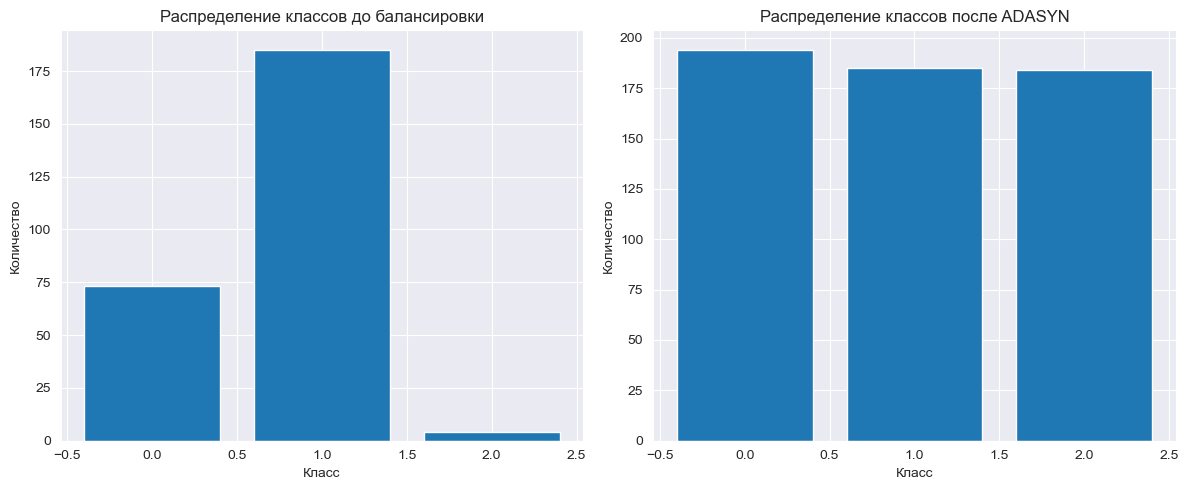

In [20]:

train_class_dist = Counter(y_train)
n_neighbors_adasyn = min(5, min(train_class_dist.values()) - 1)
n_neighbors_adasyn = max(1, n_neighbors_adasyn)  

adasyn = ADASYN(
        sampling_strategy='auto',
        random_state=42,
        n_neighbors=n_neighbors_adasyn
)

X_train_bal, y_train_bal = adasyn.fit_resample(X_train_scaled, y_train)

print(f"  До балансировки: {dict(train_class_dist)}")
print(f"  После ADASYN: {dict(Counter(y_train_bal))}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
counts_before = [train_class_dist[i] for i in sorted(train_class_dist.keys())]
bars1 = plt.bar(range(len(counts_before)), counts_before)
plt.title('Распределение классов до балансировки')
plt.xlabel('Класс')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
counts_after = [Counter(y_train_bal)[i] for i in sorted(Counter(y_train_bal).keys())]
bars2 = plt.bar(range(len(counts_after)), counts_after)
plt.title('Распределение классов после ADASYN')
plt.xlabel('Класс')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()


Подбираем гиперпараметры (Grid Search CV) для моделей:
- Decision Tree 
- K-Nearest Neighbors (KNN)
- XGBoost 
- Random Forest
- LGBM
- Cat Boost
- Logistic Regression

In [21]:
model_results = {}

dt_model = DecisionTreeClassifier(random_state=42)

dt_params = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

dt_grid = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_params,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train_bal, y_train_bal)

print(f"Лучшие параметры: {dt_grid.best_params_}")

y_test_pred_dt = dt_grid.predict(X_test_scaled)
dt_f1 = f1_score(y_test, y_test_pred_dt, average='weighted')
dt_accuracy = accuracy_score(y_test, y_test_pred_dt)

model_results['DecisionTree'] = {
    'model': dt_grid.best_estimator_,
    'best_params': dt_grid.best_params_,
    'f1': dt_f1,
    'accuracy': dt_accuracy,
    'cv_score': dt_grid.best_score_
}

print(f"F1-score: {dt_f1:.4f}")
print(f"Accuracy: {dt_accuracy:.4f}")

Fitting 3 folds for each of 384 candidates, totalling 1152 fits
Лучшие параметры: {'class_weight': None, 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}
F1-score: 0.7664
Accuracy: 0.7660


In [22]:
knn_model = KNeighborsClassifier()

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # Для minkowski
}

knn_grid = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_params,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train_bal, y_train_bal)

print(f"Лучшие параметры: {knn_grid.best_params_}")

y_test_pred_knn = knn_grid.predict(X_test_scaled)
knn_f1 = f1_score(y_test, y_test_pred_knn, average='weighted')
knn_accuracy = accuracy_score(y_test, y_test_pred_knn)

model_results['KNN'] = {
    'model': knn_grid.best_estimator_,
    'best_params': knn_grid.best_params_,
    'f1': knn_f1,
    'accuracy': knn_accuracy,
    'cv_score': knn_grid.best_score_
}

print(f"F1-score: {knn_f1:.4f}")
print(f"Accuracy: {knn_accuracy:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
F1-score: 0.8530
Accuracy: 0.8511


In [23]:
xgb_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1
)

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_bal, y_train_bal)

print(f"Лучшие параметры: {xgb_grid.best_params_}")

y_test_pred_xgb = xgb_grid.predict(X_test_scaled)
xgb_f1 = f1_score(y_test, y_test_pred_xgb, average='weighted')
xgb_accuracy = accuracy_score(y_test, y_test_pred_xgb)

model_results['XGBoost'] = {
    'model': xgb_grid.best_estimator_,
    'best_params': xgb_grid.best_params_,
    'f1': xgb_f1,
    'accuracy': xgb_accuracy,
    'cv_score': xgb_grid.best_score_
}

print(f"F1-score: {xgb_f1:.4f}")
print(f"Accuracy: {xgb_accuracy:.4f}")

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Лучшие параметры: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.9}
F1-score: 0.8652
Accuracy: 0.8723


In [24]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_bal, y_train_bal)

print(f"Лучшие параметры: {rf_grid.best_params_}")

y_test_pred_rf = rf_grid.predict(X_test_scaled)
rf_f1 = f1_score(y_test, y_test_pred_rf, average='weighted')
rf_accuracy = accuracy_score(y_test, y_test_pred_rf)

model_results['RandomForest'] = {
    'model': rf_grid.best_estimator_,
    'best_params': rf_grid.best_params_,
    'f1': rf_f1,
    'accuracy': rf_accuracy,
    'cv_score': rf_grid.best_score_
}

print(f"F1-score: {rf_f1:.4f}")
print(f"Accuracy: {rf_accuracy:.4f}")

Fitting 3 folds for each of 405 candidates, totalling 1215 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
F1-score: 0.8652
Accuracy: 0.8723


In [25]:
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

lgb_params = {
    'n_estimators': [100, 200, 300],
    'num_leaves': [20, 31, 40, 50],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, -1],
    'subsample': [0.7, 0.8, 0.9]
}

lgb_grid = GridSearchCV(
    estimator=lgb_model,
    param_grid=lgb_params,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

lgb_grid.fit(X_train_bal, y_train_bal)

print(f"Лучшие параметры: {lgb_grid.best_params_}")

y_test_pred_lgb = lgb_grid.predict(X_test_scaled)
lgb_f1 = f1_score(y_test, y_test_pred_lgb, average='weighted')
lgb_accuracy = accuracy_score(y_test, y_test_pred_lgb)

model_results['LightGBM'] = {
    'model': lgb_grid.best_estimator_,
    'best_params': lgb_grid.best_params_,
    'f1': lgb_f1,
    'accuracy': lgb_accuracy,
    'cv_score': lgb_grid.best_score_
}

print(f"F1-score: {lgb_f1:.4f}")
print(f"Accuracy: {lgb_accuracy:.4f}")

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'num_leaves': 31, 'subsample': 0.7}
F1-score: 0.8652
Accuracy: 0.8723


In [26]:
cat_model = CatBoostClassifier(
    random_seed=42,
    verbose=0
)

cat_params = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 10]
}

cat_grid = GridSearchCV(
    estimator=cat_model,
    param_grid=cat_params,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

cat_grid.fit(X_train_bal, y_train_bal)

print(f"Лучшие параметры: {cat_grid.best_params_}")

y_test_pred_cat = cat_grid.predict(X_test_scaled)
cat_f1 = f1_score(y_test, y_test_pred_cat, average='weighted')
cat_accuracy = accuracy_score(y_test, y_test_pred_cat)

model_results['CatBoost'] = {
    'model': cat_grid.best_estimator_,
    'best_params': cat_grid.best_params_,
    'f1': cat_f1,
    'accuracy': cat_accuracy,
    'cv_score': cat_grid.best_score_
}

print(f"F1-score: {cat_f1:.4f}")
print(f"Accuracy: {cat_accuracy:.4f}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Лучшие параметры: {'depth': 8, 'iterations': 300, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
F1-score: 0.8652
Accuracy: 0.8723


In [27]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2', 'elasticnet'],
    'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_params,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_bal, y_train_bal)

print(f"Лучшие параметры: {lr_grid.best_params_}")

y_test_pred_lr = lr_grid.predict(X_test_scaled)
lr_f1 = f1_score(y_test, y_test_pred_lr, average='weighted')
lr_accuracy = accuracy_score(y_test, y_test_pred_lr)

model_results['LogisticRegression'] = {
    'model': lr_grid.best_estimator_,
    'best_params': lr_grid.best_params_,
    'f1': lr_f1,
    'accuracy': lr_accuracy,
    'cv_score': lr_grid.best_score_
}

print(f"F1-score: {lr_f1:.4f}")
print(f"Accuracy: {lr_accuracy:.4f}")

Fitting 3 folds for each of 96 candidates, totalling 288 fits
Лучшие параметры: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
F1-score: 0.7563
Accuracy: 0.7447


**Вывод:** Для сравнения выбраны 7 моделей: Decision Tree, KNN, XGBoost, RandomForest, LGBM, CatBoost и Logistic Regression. Использование ADASYN для балансировки данных помогло решить проблему дисбаланса классов. Для каждой модели выполнен GridSearchCV. 



## Выбор лучшей модели и объяснение выбора

Сравним модели по F1

In [28]:
results_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'F1-Score': [model_results[m]['f1'] for m in model_results],
    'Accuracy': [model_results[m]['accuracy'] for m in model_results],
    'CV Score': [model_results[m]['cv_score'] for m in model_results]
})

results_df = results_df.sort_values('F1-Score', ascending=False)
print("\nСравнение результатов всех моделей (отсортировано по F1-Score):")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_model = model_results[best_model_name]['model']
best_f1 = results_df.iloc[0]['F1-Score']
best_params = model_results[best_model_name]['best_params']


Сравнение результатов всех моделей (отсортировано по F1-Score):
             Model  F1-Score  Accuracy  CV Score
           XGBoost  0.865210  0.872340  0.939695
      RandomForest  0.865210  0.872340  0.932410
          LightGBM  0.865210  0.872340  0.934360
          CatBoost  0.865210  0.872340  0.942893
               KNN  0.853020  0.851064  0.934999
      DecisionTree  0.766393  0.765957  0.907173
LogisticRegression  0.756295  0.744681  0.879471


Посмотрим на метрики лучшей модели 

In [29]:
y_test_pred_best = best_model.predict(X_test_scaled)

best_metrics = {
    'accuracy': accuracy_score(y_test, y_test_pred_best),
    'f1_weighted': f1_score(y_test, y_test_pred_best, average='weighted'),
    'f1_macro': f1_score(y_test, y_test_pred_best, average='macro'),
    'precision_weighted': precision_score(y_test, y_test_pred_best, average='weighted'),
    'recall_weighted': recall_score(y_test, y_test_pred_best, average='weighted')
}

In [30]:
print("\nФинальные метрики на тестовой выборке:")
for metric_name, value in best_metrics.items():
    print(f"  {metric_name}: {value:.4f}")

cm = confusion_matrix(y_test, y_test_pred_best)
print("\nМатрица ошибок:")
print(cm)


Финальные метрики на тестовой выборке:
  accuracy: 0.8723
  f1_weighted: 0.8652
  f1_macro: 0.5779
  precision_weighted: 0.8643
  recall_weighted: 0.8723

Матрица ошибок:
[[12  1  0]
 [ 4 29  0]
 [ 0  1  0]]


**Вывод:** На основе сравнения метрик F1, лучшей моделью оказался XGBoost.

## Предсказание на тестовых данных


Предскажем на итоговом датасете и сохраним файл 

In [31]:

kaggle_predictions = best_model.predict(X_test_kaggle_scaled)

submission = pd.DataFrame({
    'index': range(len(kaggle_predictions)),
    'Onshore/Offshore': kaggle_predictions
})

submission_filename = 'submission_final.csv'
submission.to_csv(submission_filename, index=False)
